# Future Stock Price Prediction

Predict the next day's closing stock price using historical stock market data and machine learning regression models.

# Library Setup

Import the required libraries for data collection, processing, visualization, and machine learning.

In [98]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print('All libraries are loaded successfully!') 

All libraries are loaded successfully!


# Data Collection

Download the latest 2 years of historical NVIDIA stock market data from Yahoo Finance using the yfinance library.

In [99]:
# NVIDIA last two years data
ticker = 'NVDA' 
df = yf.download(ticker, period = '2y')
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(501, 5)


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-06-20,130.564804,140.528378,129.306883,139.569966,517768400
2024-06-21,126.361740,130.415065,124.095479,126.910838,649445800
2024-06-24,117.915642,124.255191,117.845757,123.037197,476060900
2024-06-25,125.882507,126.291836,119.123651,121.000555,414192600
2024-06-26,126.192024,127.909188,122.398274,125.922464,362975900


# Feature Engineering and Data Preparation

Create the next day closing price as the target variable and prepare input features for model training.

In [100]:
# Create a today-tomorrow relationship
df['Next_Close'] = df['Close'].shift(-1)

# Drop last row with NaN 
df = df.dropna()

# Select features X and y
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

df.head()

Features shape: (500, 5)
Target shape: (500,)


Price,Close,High,Low,Open,Volume,Next_Close
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,
Date,,,,,,
2024-06-20,130.564804,140.528378,129.306883,139.569966,517768400,126.361740
2024-06-21,126.361740,130.415065,124.095479,126.910838,649445800,117.915642
2024-06-24,117.915642,124.255191,117.845757,123.037197,476060900,125.882507
2024-06-25,125.882507,126.291836,119.123651,121.000555,414192600,126.192024
2024-06-26,126.192024,127.909188,122.398274,125.922464,362975900,123.785980


# Train-Test Split

Divide the data into training and testing sets while preserving chronological order.

In [101]:
# 80/20 data split

# shuffle false for time-based order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle= False
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 400
Testing samples: 100


# Model Training

Train a Random Forest Regressor on the training data to learn patterns for predicting future stock prices.

In [102]:
model = RandomForestRegressor(
    n_estimators= 300,
    max_depth= 8,
    min_samples_split= 5,
    random_state= 42)
model.fit(X_train, y_train)

print('Model trained!')

Model trained!


# Model Evaluation

Measure prediction performance using Mean Absolute Error (MAE) and R² Score.

In [103]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: $7.00
R2 Score: 0.6509


# Model Evaluation

Make predictions on test data and evaluate performance using MAE and R² score.

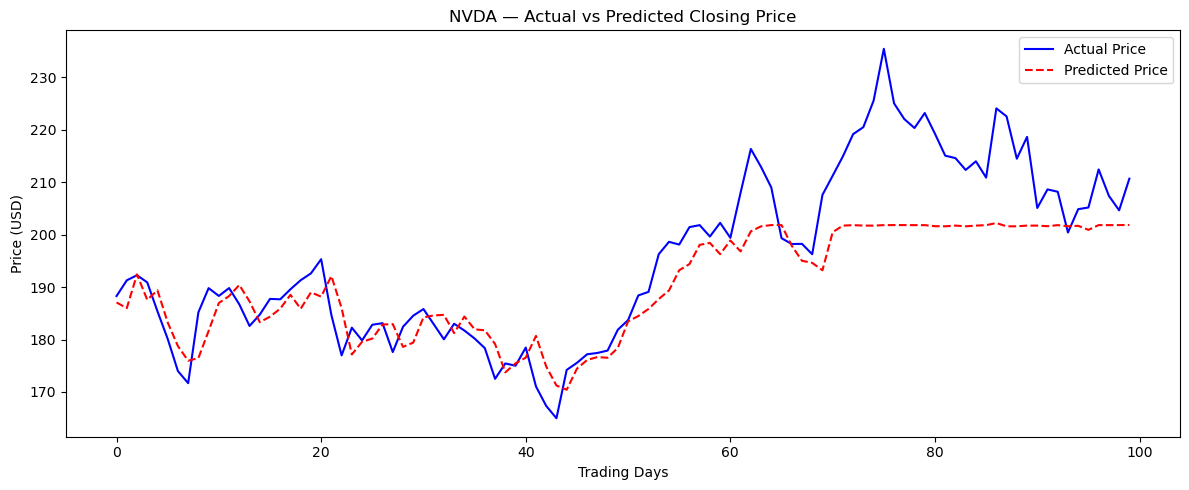

In [104]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price', color='red', linewidth=1.5, linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Project Summary

* Collected 2 years of historical **NVIDIA (NVDA)** stock data from **Yahoo Finance** using the `yfinance` library.
* Performed data exploration to understand key stock attributes like Open, High, Low, Close, and Volume.
* Engineered the target variable `Next_Close` by shifting the Close price to represent the next day’s closing value.
* Prepared the dataset by selecting relevant features (Open, High, Low, Volume, Close) and removing missing values.
* Split the dataset into training (80%) and testing (20%) sets while maintaining chronological order using `shuffle=False`.
* Trained a Random Forest Regressor model to learn patterns from historical stock data and predict future prices.
* Evaluated model performance using Mean Absolute Error (MAE) and R² score to measure prediction accuracy.
* Achieved an MAE of approximately **$7.00** and an R² score of **0.6509**, indicating moderate predictive performance.
* Visualized actual vs predicted closing prices to compare model predictions against real market behavior.
